# Pagamento de Horas Extraordinárias (Referência_Ano de 2023)

link está aqui: https://dados.gov.br/dados/conjuntos-dados/24-pagamento-de-horas-extraordinarias

para abaixar o conteudo do arquivo acesse: https://www.gov.br/ebserh/pt-br/hospitais-universitarios/regiao-nordeste/huol-ufrn/acesso-a-informacao/dados-abertos-1/24%20-%20Pagamento%20de%20Horas%20Extraordinarias/24-pagamento-de-horas-extraordinarias-referencia_-ano-de-2023.csv/@@download/file

## Orgão responsável pela publicação: **EBSERH - Filial Hospital Universitário Onofre Lopes**

**Descrição do tema e sua finalidade:** Relação contendo total de pagamentos de horas extraordinárias e Adicional por Plantão Hospitalar - APH dos empregados lotados no Hospital Universitário Onofre Lopes (Huol), por cargo. A responsabilidade pela base é da Unidade de Administração de Pessoal.

**Número de registro e colunas: ** 3 colunas e 110 linhas.

**Significado de algumas variáveis importantes:**
1. Cargos
2. Total de Horas
3. Números de plantões.
4. HORAS EXTRAORDINÁRIAS (Vínculo CLT/Ebserh) com referentes do mês

**Importante**:
- Os Cargos são divididos por: Analista Administrativo, Assistentes Administrativo, Enfermeiro, Técnico de Saúde, Auxiliar de Enfermagem, Famacêutico, Técnico de Enfermagem, Técnico em Laboratório.

- Total de Horas são o Total de Horas trabalhadas pelo mês referente.

- Números de plantões é referente ao mês trabalhado.

Este Trabalho é uma atividade Escolar pela disciplina: **Ciência dos Dados**, pelo Professor: **Luis Cueves**, foi feito pelo aluno: **Daniel Nazário**.

Será feito a Exploração de Dados Público com Estatística Descritiva, usando os dados do governo brasileiro: https://dados.gov.br/dados/conjuntos-dados

O dataset de interesse foi de **Economia e Finanças**, por que é um tema interessante para verificação dos dados brutos, para Verificação de Pagamento de Horas Extraordinárias do **Hospital Universitário Onofre Lopes**.

Será feito a Exploração Estística no Notebook usando Google Colab.
Ulitizando o **Python** com pandas,numpy,matplotib e/ou seaborn para:

**Calcular estatística descritivas:**

- Média, mediana, moda;
- Mínimo, Máximo;
- Desvio, Padrão. variância;
- Quartis e intervalo interquartil(IQR);

**Gerar visualizações como:**
- Histogramas, boxplots e gráticos de dispersão

Logo comentar os resultados: **que padrões ou irregularidades foi observado?**

# Primeiro passo:

1. Fazer o Download do governo brasileiro: https://www.google.com/url?q=https%3A%2F%2Fdados.gov.br%2Fdados%2Fconjuntos-dados

2. Importar as Bibliotecas pandas, numpy, matplotlib e seaborn.

3. Inspecionar os Dados e Valores Ausentes verificando o seu tipo de dado.

4. Estatísticas Descritivas

In [5]:
# Passo 1: Preparação e Limpeza dos Dados

# Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

# 1. Carregar os dados (pulando as 5 linhas de cabeçalho do governo)
caminho = '24. Pagamento de Horas Extraordinárias (Referência_ Ano de 2023).csv'
df = pd.read_csv(caminho, encoding='latin1', sep=';', skiprows=5)

# 2. Pegar apenas as 3 primeiras colunas e renomeá-las
df = df.iloc[:, 0:3]
df.columns = ['Mes', 'Cargo', 'Total_Horas']

# 3. Criar a "White List" (Apenas cargos reais do hospital)
cargos_validos = [
    'Analista Administrativo',
    'Assistente Administrativo',
    'Enfermeiro',
    'Técnico em Saúde',
    'Farmacêutico',
    'Técnico em Laboratório'
]

# 4. Filtrar a tabela para manter SÓ o que está na nossa lista
df_limpo = df[df['Cargo'].isin(cargos_validos)].copy()

# 5. Converter a coluna de horas (trocar vírgula por ponto e transformar em número)
df_limpo['Total_Horas'] = df_limpo['Total_Horas'].astype(str).str.replace(',', '.')
df_limpo['Total_Horas'] = pd.to_numeric(df_limpo['Total_Horas'], errors='coerce')

# 6. Remover linhas que ficaram sem horas e organizar a tabela
df_limpo = df_limpo.dropna(subset=['Total_Horas']).reset_index(drop=True)

print("Dados limpos com sucesso! Primeiras linhas:")
display(df_limpo.head())

Dados limpos com sucesso! Primeiras linhas:


,Mes,Cargo,Total_Horas
0,MARÇO,Analista Administrativo,17.25
1,MARÇO,Assistente Administrativo,162.47
2,MARÇO,Enfermeiro,32.02
3,MARÇO,Técnico em Saúde,4.52
4,NOVEMBRO,Enfermeiro,174.00


In [6]:
# Passo 2: Contar Valores Ausentes e Tipos de Dados

print("--- Tipos de Dados ---")
print(df_limpo.dtypes) # Total_Horas precisa ser 'float64'

print("\n--- Contagem de Valores Ausentes ---")
print(df_limpo.isnull().sum()) # O ideal é que tudo seja zero aqui

--- Tipos de Dados ---
Mes             object
Cargo           object
Total_Horas    float64
dtype: object

--- Contagem de Valores Ausentes ---
Mes            0
Cargo          0
Total_Horas    0
dtype: int64


In [7]:
# Passo 3:Calcular Estatísticas Descritivas

horas = df_limpo['Total_Horas']

# Cálculos
media = horas.mean()
mediana = horas.median()
moda = horas.mode()[0]
minimo = horas.min()
maximo = horas.max()
desvio_padrao = horas.std()
variancia = horas.var()
q1 = horas.quantile(0.25)
q3 = horas.quantile(0.75)
iqr = q3 - q1

# Exibição
print("--- ESTATÍSTICAS DESCRITIVAS: HORAS EXTRAS ---")
print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda: {moda:.2f}\n")
print(f"Mínimo: {minimo:.2f} | Máximo: {maximo:.2f}\n")
print(f"Desvio Padrão: {desvio_padrao:.2f} | Variância: {variancia:.2f}\n")
print(f"1º Quartil (Q1): {q1:.2f}")
print(f"3º Quartil (Q3): {q3:.2f}")
print(f"Intervalo Interquartil (IQR): {iqr:.2f}")

--- ESTATÍSTICAS DESCRITIVAS: HORAS EXTRAS ---
Média: 26.75
Mediana: 17.25
Moda: 7.00

Mínimo: 4.00 | Máximo: 174.00

Desvio Padrão: 39.32 | Variância: 1546.19

1º Quartil (Q1): 7.50
3º Quartil (Q3): 27.00
Intervalo Interquartil (IQR): 19.50


C:\Users\dnods\AppData\Local\Temp\ipykernel_8116\2532011710.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cargo', y='Total_Horas', data=df_limpo, palette='Set2', ax=axes[1])


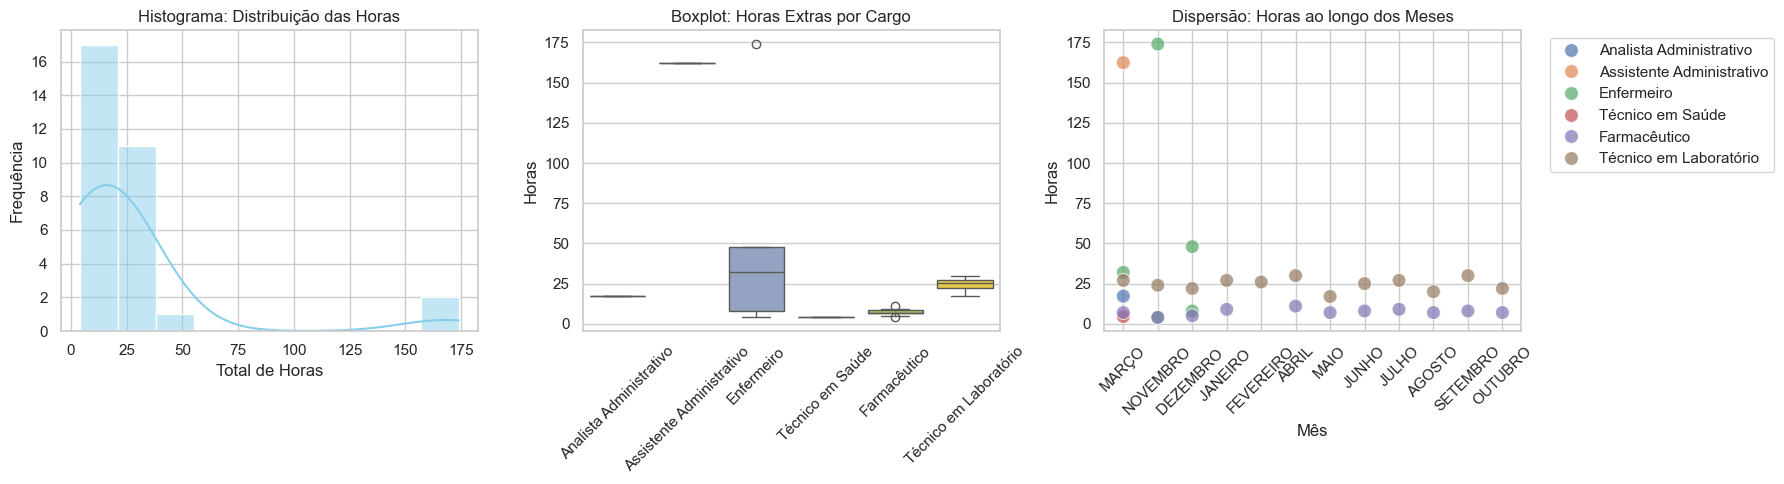

In [8]:
# Passo 4: Gerar Visualizações

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histograma (Distribuição geral das horas)
sns.histplot(df_limpo['Total_Horas'], bins=10, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Histograma: Distribuição das Horas')
axes[0].set_xlabel('Total de Horas')
axes[0].set_ylabel('Frequência')

# 2. Boxplot (Dispersão agrupada por Cargo para ver quem faz mais horas)
sns.boxplot(x='Cargo', y='Total_Horas', data=df_limpo, palette='Set2', ax=axes[1])
axes[1].set_title('Boxplot: Horas Extras por Cargo')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('')
axes[1].set_ylabel('Horas')

# 3. Gráfico de Dispersão (Scatterplot - Horas ao longo dos meses)
sns.scatterplot(x='Mes', y='Total_Horas', hue='Cargo', data=df_limpo, s=100, alpha=0.7, ax=axes[2])
axes[2].set_title('Dispersão: Horas ao longo dos Meses')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_xlabel('Mês')
axes[2].set_ylabel('Horas')
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Coloca a legenda fora do gráfico

plt.tight_layout()
plt.show()